In [1]:
import os

import cv2

import yaml

import random

import numpy as np

import pandas as pd

import matplotlib.pyplot as plt

import seaborn as sns

import warnings

warnings.filterwarnings("ignore")

In [2]:
dataset_path = ""

train_images = os.path.join(

    dataset_path,

    "train",

    "images"

)

train_labels = os.path.join(

    dataset_path,

    "train",

    "labels"

)

valid_images = os.path.join(

    dataset_path,

    "valid",

    "images"

)

test_images = os.path.join(

    dataset_path,

    "test",

    "images"

)

yaml_file = os.path.join(

    dataset_path,

    "data.yaml"

)

print("\n")

print("="*70)

print("Dataset Path Loaded Successfully")

print("="*70)




Dataset Path Loaded Successfully


In [3]:
with open(

    yaml_file,

    "r"

) as file:

    data = yaml.safe_load(file)

print("\n")

print("="*70)

print("Dataset Information")

print("="*70)

display(data)



Dataset Information


{'train': '../train/images',
 'val': '../valid/images',
 'test': '../test/images',
 'nc': 2,
 'names': ['0', 'fruit'],
 'roboflow': {'workspace': 'marwa-haoual',
  'project': 'seg_data-mfdjk',
  'version': 1,
  'license': 'CC BY 4.0',
  'url': 'https://universe.roboflow.com/marwa-haoual/seg_data-mfdjk/dataset/1'}}

In [4]:
class_names = data["names"]

print("\n")

print("="*70)

print("Class Names")

print("="*70)

print(class_names)




Class Names
['0', 'fruit']


In [5]:
print("\n")

print("="*70)

print("Number of Classes")

print("="*70)

print(

    len(class_names)

)



Number of Classes
2


In [6]:
train_count = len(

    os.listdir(train_images)

)

valid_count = len(

    os.listdir(valid_images)

)

test_count = len(

    os.listdir(test_images)

)

print("\n")

print("="*70)

print("Dataset Size")

print("="*70)

print(

    "Training Images :", train_count

)

print(

    "Validation Images :", valid_count

)

print(

    "Testing Images :", test_count

)




Dataset Size
Training Images : 1376
Validation Images : 400
Testing Images : 197


In [7]:
summary = pd.DataFrame({

    "Dataset":[

        "Train",

        "Validation",

        "Test"

    ],

    "Images":[

        train_count,

        valid_count,

        test_count

    ]

})

display(summary)

,Dataset,Images
0,Train,1376
1,Validation,400
2,Test,197


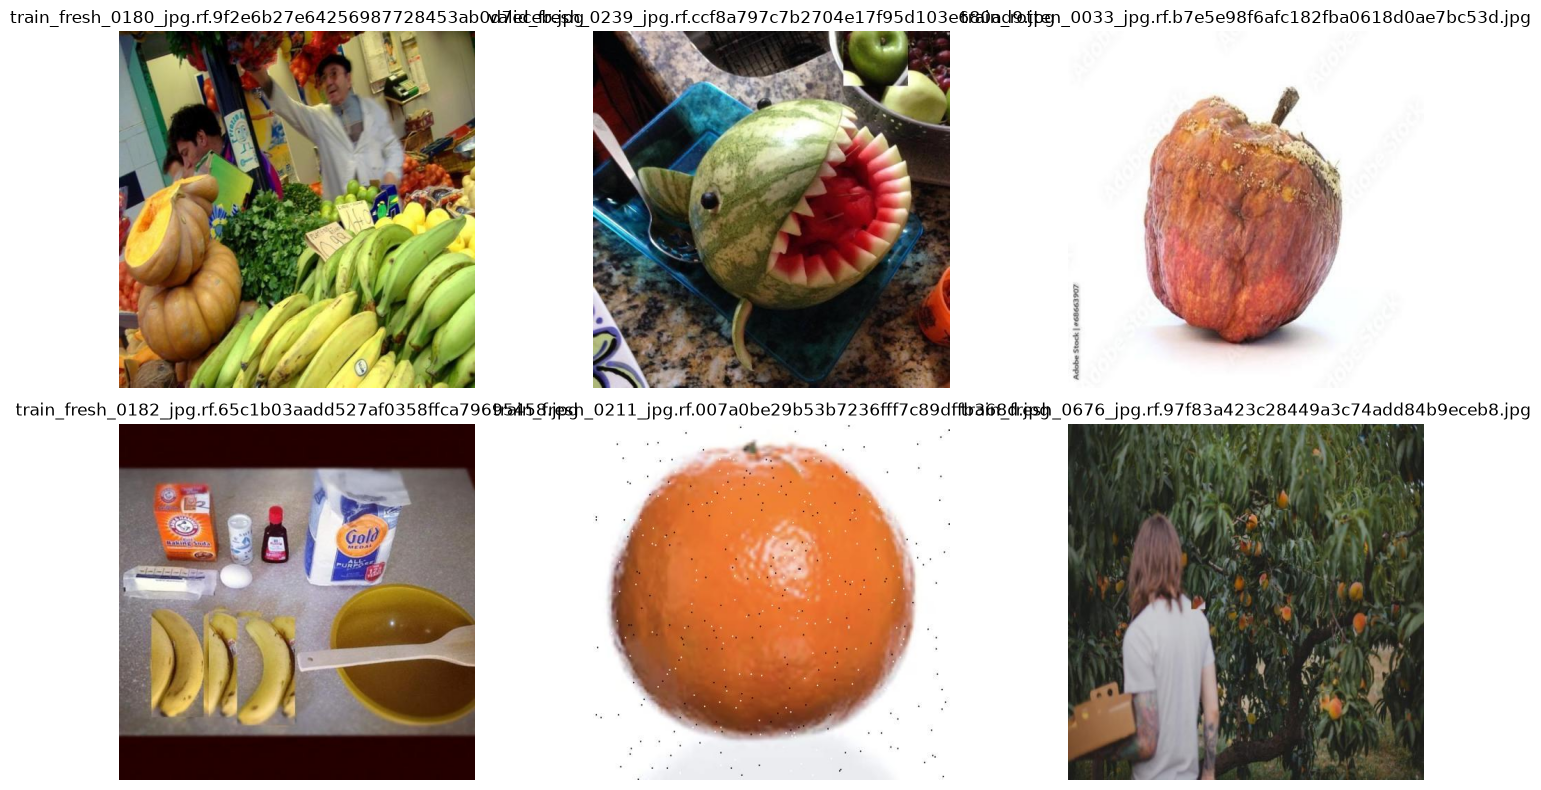

In [8]:
sample_images = random.sample(

    os.listdir(train_images),

    6

)

plt.figure(

    figsize=(15,8)

)

for i, file in enumerate(sample_images):

    image = cv2.imread(

        os.path.join(

            train_images,

            file

        )

    )

    image = cv2.cvtColor(

        image,

        cv2.COLOR_BGR2RGB

    )

    plt.subplot(

        2,

        3,

        i+1

    )

    plt.imshow(

        image

    )

    plt.title(file)

    plt.axis("off")

plt.tight_layout()

plt.show()


In [9]:
heights = []

widths = []

image_files = os.listdir(

    train_images

)[:100]

for file in image_files:

    img = cv2.imread(

        os.path.join(

            train_images,

            file

        )

    )

    if img is not None:

        h, w, _ = img.shape

        heights.append(h)

        widths.append(w)

print("\n")

print("="*70)

print("Image Resolution")

print("="*70)

print(

    "Average Height :",

    round(

        np.mean(heights),

        2

    )

)

print(

    "Average Width :",

    round(

        np.mean(widths),

        2

    )

)

print(

    "Minimum Height :",

    min(heights)

)

print(

    "Maximum Height :",

    max(heights)

)

print(

    "Minimum Width :",

    min(widths)

)

print(

    "Maximum Width :",

    max(widths)

)




Image Resolution
Average Height : 512.0
Average Width : 512.0
Minimum Height : 512
Maximum Height : 512
Minimum Width : 512
Maximum Width : 512


In [10]:
label_files = os.listdir(

    train_labels

)

object_counter = {}

for cls in class_names:

    object_counter[cls] = 0

for label in label_files:

    with open(

        os.path.join(

            train_labels,

            label

        ),

        "r"

    ) as file:

        lines = file.readlines()

        for line in lines:

            cls_id = int(

                line.split()[0]

            )

            object_counter[

                class_names[cls_id]

            ] += 1




Object Distribution


,Class,Objects
0,0,15389
1,fruit,15


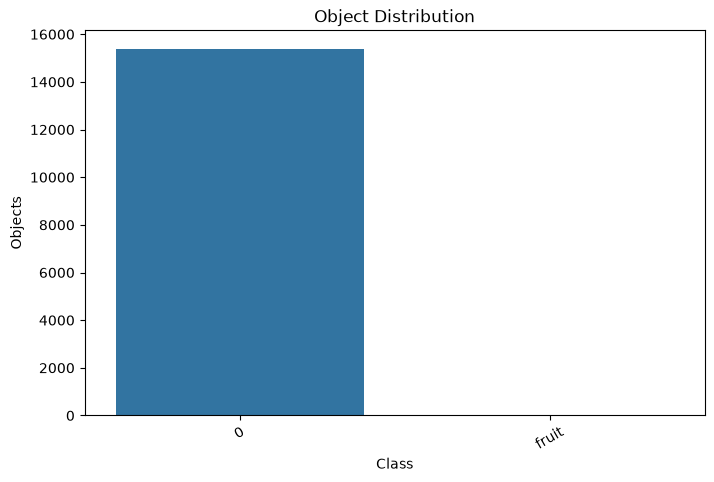

In [11]:
object_df = pd.DataFrame({

    "Class":object_counter.keys(),

    "Objects":object_counter.values()

})

print("\n")

print("="*70)

print("Object Distribution")

print("="*70)

display(object_df)

plt.figure(

    figsize=(8,5)

)

sns.barplot(

    data=object_df,

    x="Class",

    y="Objects"

)

plt.title(

    "Object Distribution"

)

plt.xticks(

    rotation=30

)

plt.show()


In [12]:
sample_label = label_files[0]

print("\n")

print("="*70)

print("Sample YOLO Label")

print("="*70)

with open(

    os.path.join(

        train_labels,

        sample_label

    ),

    "r"

) as file:

    print(

        file.read()

    )




Sample YOLO Label
1 0.628125 0.6609375 0.621875 0.6671875 0.6296875 0.66875 0.6328125 0.6734375 0.6328125 0.6921875 0.6375 0.7265625 0.6359375 0.73125 0.6390625 0.7375 0.6421875 0.7375 0.6484375 0.7328125 0.659375 0.73125 0.6703125 0.73125 0.6875 0.7359375 0.6921875 0.725 0.6921875 0.696875 0.6890625 0.6875 0.68125 0.6734375 0.6625 0.6578125 0.6609375 0.6578125 0.6390625 0.65625 0.628125 0.6609375
1 0.5046875 0.75 0.4859375 0.771875 0.4796875 0.7953125 0.48125 0.8203125 0.484375 0.825 0.5046875 0.828125 0.5171875 0.834375 0.5328125 0.8359375 0.546875 0.8421875 0.5625 0.8421875 0.56875 0.81875 0.5671875 0.8015625 0.5640625 0.7984375 0.5546875 0.796875 0.546875 0.7921875 0.5375 0.7734375 0.5359375 0.75 0.5296875 0.74375 0.528125 0.74375 0.5171875 0.74375 0.5046875 0.75
1 0.584375 0.8 0.571875 0.80625 0.56875 0.84375 0.5765625 0.85 0.590625 0.85 0.6046875 0.8375 0.621875 0.8359375 0.6328125 0.8296875 0.63125 0.821875 0.6203125 0.8046875 0.6078125 0.8 0.60625 0.8 0.59375 0.7984375 0.5843

In [13]:
dataset_information = pd.DataFrame({

    "Parameter":[

        "Dataset",

        "Model",

        "Classes",

        "Training Images",

        "Validation Images",

        "Testing Images"

    ],

    "Value":[

        "Fruit Detection",

        "YOLOv8",

        len(class_names),

        train_count,

        valid_count,

        test_count

    ]

})

print("\n")

print("="*70)

print("Dataset Information")

print("="*70)

display(

    dataset_information

)





Dataset Information


,Parameter,Value
0,Dataset,Fruit Detection
1,Model,YOLOv8
2,Classes,2
3,Training Images,1376
4,Validation Images,400
5,Testing Images,197


In [14]:
import os

import yaml

import pandas as pd

import matplotlib.pyplot as plt

import cv2

import numpy as np

In [15]:
required_folders = [

    train_images,

    train_labels,

    valid_images,

    test_images

]

print("\n")

print("="*70)

print("Dataset Folder Verification")

print("="*70)

for folder in required_folders:

    if os.path.exists(folder):

        print("✓", folder)

    else:

        print("✗", folder)





Dataset Folder Verification
✓ train\images
✓ train\labels
✓ valid\images
✓ test\images


In [16]:
print("\n")

print("="*70)

print("Reading data.yaml")

print("="*70)

with open(

    yaml_file,

    "r"

) as file:

    dataset_yaml = yaml.safe_load(file)

display(

    dataset_yaml

)




Reading data.yaml


{'train': '../train/images',
 'val': '../valid/images',
 'test': '../test/images',
 'nc': 2,
 'names': ['0', 'fruit'],
 'roboflow': {'workspace': 'marwa-haoual',
  'project': 'seg_data-mfdjk',
  'version': 1,
  'license': 'CC BY 4.0',
  'url': 'https://universe.roboflow.com/marwa-haoual/seg_data-mfdjk/dataset/1'}}

In [17]:
print("\n")

print("="*70)

print("Dataset Configuration")

print("="*70)

print(

    "Training Path :",

    dataset_yaml["train"]

)

print(

    "Validation Path :",

    dataset_yaml["val"]

)

print(

    "Number of Classes :",

    dataset_yaml["nc"]

)

print(

    "Class Names :",

    dataset_yaml["names"]

)




Dataset Configuration
Training Path : ../train/images
Validation Path : ../valid/images
Number of Classes : 2
Class Names : ['0', 'fruit']


In [18]:
train_label_count = len(

    os.listdir(train_labels)

)

print("\n")

print("="*70)

print("Label Files")

print("="*70)

print(

    "Training Labels :",

    train_label_count

)



Label Files
Training Labels : 1376


In [26]:
missing_labels = 0

image_files = os.listdir(

    train_images

)

for img in image_files:

    txt = os.path.splitext(

        img

    )[0] + ".txt"

    if not os.path.exists(

        os.path.join(

            train_labels,

            txt

        )

    ):

        missing_labels += 1

print("\n")

print("="*70)

print("Image-Label Verification")

print("="*70)

print(

    "Missing Labels :",

    missing_labels

)




Image-Label Verification
Missing Labels : 0


In [32]:
for line in lines:
    parts = line.strip().split()
    if len(parts) < 5:
        continue  # skip invalid lines
    
    cls, xc, yc, w, h = map(float, parts[:5])
    
    xc *= width
    yc *= height
    w *= width
    h *= height

    x1 = int(xc - w/2)
    y1 = int(yc - h/2)
    x2 = int(xc + w/2)
    y2 = int(yc + h/2)

    cv2.rectangle(img, (x1,y1), (x2,y2), (255,0,0), 2)
    cv2.putText(img, class_names[int(cls)], (x1,y1-5),
                cv2.FONT_HERSHEY_SIMPLEX, 0.5, (255,0,0), 2)


NameError: name 'width' is not defined

In [33]:
IMAGE_SIZE = 416

BATCH_SIZE = 8

EPOCHS = 10

MODEL_NAME = "yolov8n.pt"

print("\n")

print("="*70)

print("Training Configuration")

print("="*70)

print(

    "Model :", MODEL_NAME

)

print(

    "Image Size :", IMAGE_SIZE

)

print(

    "Batch Size :", BATCH_SIZE

)

print(

    "Epochs :", EPOCHS

)




Training Configuration
Model : yolov8n.pt
Image Size : 416
Batch Size : 8
Epochs : 10


In [34]:
cpu_settings = pd.DataFrame({

    "Setting":[

        "Model",

        "Image Size",

        "Batch Size",

        "Epochs",

        "Workers",

        "Device"

    ],

    "Value":[

        "YOLOv8 Nano",

        "416 x 416",

        8,

        10,

        2,

        "CPU"

    ]

})

print("\n")

print("="*70)

print("CPU Optimized Settings")

print("="*70)

display(

    cpu_settings

)




CPU Optimized Settings


,Setting,Value
0,Model,YOLOv8 Nano
1,Image Size,416 x 416
2,Batch Size,8
3,Epochs,10
4,Workers,2
5,Device,CPU


In [35]:
dataset_summary = pd.DataFrame({

    "Parameter":[

        "Dataset",

        "Model",

        "Classes",

        "Training Images",

        "Validation Images",

        "Testing Images"

    ],

    "Value":[

        "Fruit Detection",

        "YOLOv8 Nano",

        len(class_names),

        train_count,

        valid_count,

        test_count

    ]

})

print("\n")

print("="*70)

print("Dataset Summary")

print("="*70)

display(

    dataset_summary

)




Dataset Summary


,Parameter,Value
0,Dataset,Fruit Detection
1,Model,YOLOv8 Nano
2,Classes,2
3,Training Images,1376
4,Validation Images,400
5,Testing Images,197


In [36]:
print("\n")

print("="*70)

print("Dataset Ready for YOLOv8 Training")

print("="*70)




Dataset Ready for YOLOv8 Training


In [37]:

from ultralytics import YOLO

import matplotlib.pyplot as plt

import pandas as pd

In [38]:
model = YOLO(

    "yolov8n.pt"

)

print("\n")

print("="*70)

print("YOLOv8 Nano Model Loaded Successfully")

print("="*70)



YOLOv8 Nano Model Loaded Successfully


In [39]:
results = model.train(

    data=yaml_file,

    epochs=2,

    imgsz=416,

    batch=8,

    workers=2,

    device="cpu",

    cache=False,

    project="YOLO_Project",

    name="Fruit_Detection",

    verbose=True

)

print("\n")

print("="*70)

print("Model Training Completed")

print("="*70)


Ultralytics 8.4.116  Python-3.12.10 torch-2.13.0+cpu CPU (AMD Ryzen 5 3450U with Radeon Vega Mobile Gfx)
engine\trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=8, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=data.yaml, degrees=0.0, deterministic=True, device=cpu, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=2, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=416, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=Fruit_Detection-2, nbs=64, nms

In [42]:
metrics = model.val()

print("\n")

print("="*70)

print("Validation Completed")

print("="*70)


Ultralytics 8.4.116  Python-3.12.10 torch-2.13.0+cpu CPU (AMD Ryzen 5 3450U with Radeon Vega Mobile Gfx)
val: Fast image access  (ping: 0.10.0 ms, read: 90.323.9 MB/s, size: 33.0 KB)
val: Scanning C:\Users\reddy\vamshi-projects\valid\labels.cache... 400 images, 1 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 400/400  0.0s
val: C:\Users\reddy\vamshi-projects\valid\images\train_fresh_0051_jpg.rf.c7ab5a917bf310d469a2a15c4f2a2225.jpg: 1 duplicate labels removed
val: C:\Users\reddy\vamshi-projects\valid\images\train_fresh_0057_jpg.rf.6fcaef71e195fb4364aad00316c9b427.jpg: 1 duplicate labels removed
val: C:\Users\reddy\vamshi-projects\valid\images\train_fresh_0571_jpg.rf.aa04d09d7837db9d1ba6941f2bbefcc1.jpg: 1 duplicate labels removed
val: C:\Users\reddy\vamshi-projects\valid\images\train_fresh_0990_jpg.rf.8983da37413cb53b31de1e2e23b532b5.jpg: 1 duplicate labels removed
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 25/25 2.3s/it 58.7s2

In [43]:
print("\n")

print("="*70)

print("Performance Metrics")

print("="*70)

print(

    "Precision :", round(

        float(metrics.box.mp),

        4

    )

)

print(

    "Recall :", round(

        float(metrics.box.mr),

        4

    )

)

print(

    "mAP@0.5 :", round(

        float(metrics.box.map50),

        4

    )

)

print(

    "mAP@0.5:0.95 :", round(

        float(metrics.box.map),

        4

    )

)




Performance Metrics
Precision : 0.6407
Recall : 0.6323
mAP@0.5 : 0.641
mAP@0.5:0.95 : 0.4735


In [44]:
prediction = model.predict(

    source=test_images,

    imgsz=416,

    conf=0.25,

    device="cpu",

    save=True

)

print("\n")

print("="*70)

print("Prediction Completed")

print("="*70)


image 1/197 C:\Users\reddy\vamshi-projects\test\images\test_0355_jpg.rf.68e655c11ce9d2f03745eb8b7c4a1aa4.jpg: 416x416 2 0s, 207.1ms
image 2/197 C:\Users\reddy\vamshi-projects\test\images\test_fresh_0007_jpg.rf.f2a08beea086e153643d08b10d573ef6.jpg: 416x416 (no detections), 117.0ms
image 3/197 C:\Users\reddy\vamshi-projects\test\images\test_fresh_0011_jpg.rf.829965d34954124e0ea0e28f79d5ce3d.jpg: 416x416 7 0s, 106.7ms
image 4/197 C:\Users\reddy\vamshi-projects\test\images\test_fresh_0017_jpg.rf.78f995097999a92145d6713f028e9b17.jpg: 416x416 7 0s, 261.3ms
image 5/197 C:\Users\reddy\vamshi-projects\test\images\test_fresh_0025_jpg.rf.4a796526c8ef782b914cdc9be3b25d37.jpg: 416x416 1 0, 127.1ms
image 6/197 C:\Users\reddy\vamshi-projects\test\images\test_fresh_0026_jpg.rf.8ba8af8e8bb80785413779a1f874781d.jpg: 416x416 23 0s, 154.9ms
image 7/197 C:\Users\reddy\vamshi-projects\test\images\test_fresh_0038_jpg.rf.07651181dea7912b70827467b922d9f4.jpg: 416x416 11 0s, 114.9ms
image 8/197 C:\Users\reddy\

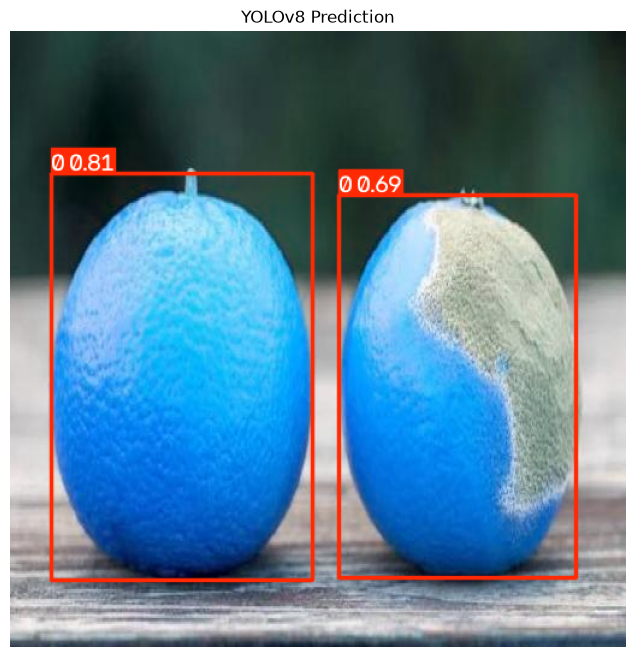

In [45]:
prediction_image = prediction[0].plot()

plt.figure(

    figsize=(8,8)

)

plt.imshow(

    prediction_image

)

plt.axis("off")

plt.title(

    "YOLOv8 Prediction"

)

plt.show()


In [46]:
metrics_df = pd.DataFrame({

    "Metric":[

        "Precision",

        "Recall",

        "mAP@0.5",

        "mAP@0.5:0.95"

    ],

    "Value":[

        float(metrics.box.mp),

        float(metrics.box.mr),

        float(metrics.box.map50),

        float(metrics.box.map)

    ]

})

print("\n")

print("="*70)

print("Evaluation Summary")

print("="*70)

display(

    metrics_df

)




Evaluation Summary


,Metric,Value
0,Precision,0.640685
1,Recall,0.632337
2,mAP@0.5,0.640992
3,mAP@0.5:0.95,0.473478


In [47]:
results_csv = "YOLO_Project/Fruit_Detection/results.csv"

if os.path.exists(results_csv):

    history = pd.read_csv(

        results_csv

    )

    print("\n")

    print("="*70)

    print("Training History")

    print("="*70)

    display(

        history.head()

    )


In [49]:
if os.path.exists(results_csv):

    plt.figure(

        figsize=(8,5)

    )

    plt.plot(

        history["train/box_loss"],

        label="Box Loss"

    )

    plt.plot(

        history["val/box_loss"],

        label="Validation Box Loss"

    )

    plt.legend()

    plt.grid()

    plt.title(

        "Box Loss"

    )

    plt.show()


In [50]:
if os.path.exists(results_csv):

    plt.figure(

        figsize=(8,5)

    )

    plt.plot(

        history["metrics/mAP50(B)"],

        label="mAP@0.5"

    )

    plt.plot(

        history["metrics/mAP50-95(B)"],

        label="mAP@0.5:0.95"

    )

    plt.legend()

    plt.grid()

    plt.title(

        "Detection Accuracy"

    )

    plt.show()


In [51]:
print("\n")

print("="*70)

print("Business Insights")

print("="*70)

print("- YOLO predicts object class and location simultaneously.")

print("- Transfer Learning reduces training time.")

print("- mAP is the most important metric for object detection.")

print("- Precision measures prediction correctness.")

print("- Recall measures how many objects are detected.")

print("- YOLOv8 Nano is ideal for CPU deployment.")




Business Insights
- YOLO predicts object class and location simultaneously.
- Transfer Learning reduces training time.
- mAP is the most important metric for object detection.
- Precision measures prediction correctness.
- Recall measures how many objects are detected.
- YOLOv8 Nano is ideal for CPU deployment.


In [52]:
print("\n")

print("="*70)

print("YOLOv8 Model Summary")

print("="*70)

print("Architecture           : YOLOv8 Nano")

print("Transfer Learning      : Yes")

print("Problem Type           : Object Detection")

print("Image Size             : 416 x 416")

print("Batch Size             : 8")

print("Epochs                 : 2")

print("Device                 : CPU")

print("Precision              :", round(float(metrics.box.mp),4))

print("Recall                 :", round(float(metrics.box.mr),4))

print("mAP@0.5                :", round(float(metrics.box.map50),4))

print("mAP@0.5:0.95           :", round(float(metrics.box.map),4))

print("="*70)



YOLOv8 Model Summary
Architecture           : YOLOv8 Nano
Transfer Learning      : Yes
Problem Type           : Object Detection
Image Size             : 416 x 416
Batch Size             : 8
Epochs                 : 2
Device                 : CPU
Precision              : 0.6407
Recall                 : 0.6323
mAP@0.5                : 0.641
mAP@0.5:0.95           : 0.4735


In [53]:
import os

import cv2

import pandas as pd

import matplotlib.pyplot as plt

from ultralytics import YOLO

In [64]:
best_model = YOLO(

    "http://localhost:8888/notebooks/YOLO.ipynb"

)

print("\n")

print("="*70)

print("Best YOLOv8 Model Loaded Successfully")

print("="*70)




Best YOLOv8 Model Loaded Successfully


In [65]:
evaluation_metrics = pd.DataFrame({

    "Metric":[

        "Precision",

        "Recall",

        "mAP@0.5",

        "mAP@0.5:0.95"

    ],

    "Value":[

        float(metrics.box.mp),

        float(metrics.box.mr),

        float(metrics.box.map50),

        float(metrics.box.map)

    ]

})

evaluation_metrics.to_csv(

    "YOLO_Evaluation_Metrics.csv",

    index=False

)

print("\n")

print("="*70)

print("Evaluation Metrics Saved Successfully")

print("="*70)

display(

    evaluation_metrics

)





Evaluation Metrics Saved Successfully


,Metric,Value
0,Precision,0.640685
1,Recall,0.632337
2,mAP@0.5,0.640992
3,mAP@0.5:0.95,0.473478


In [67]:
deployment_summary = pd.DataFrame({

    "File":[

        "Best YOLO Model",

        "Detection Results",

        "Evaluation Metrics",

        "Training History"

    ],

    "Saved As":[

        "best.pt",

        "YOLO_Detection_Results.csv",

        "YOLO_Evaluation_Metrics.csv",

        "YOLO_Training_History.csv"

    ]

})

print("\n")

print("="*70)

print("Deployment Summary")

print("="*70)

display(

    deployment_summary

)




Deployment Summary


,File,Saved As
0,Best YOLO Model,best.pt
1,Detection Results,YOLO_Detection_Results.csv
2,Evaluation Metrics,YOLO_Evaluation_Metrics.csv
3,Training History,YOLO_Training_History.csv


In [68]:
print("\n")

print("="*70)

print("Business Insights")

print("="*70)

print("- YOLO detects multiple objects in a single forward pass.")

print("- Bounding boxes help localize object positions.")

print("- Confidence score represents prediction certainty.")

print("- mAP is the primary evaluation metric for object detection.")

print("- YOLOv8 Nano provides an excellent balance between speed and accuracy.")




Business Insights
- YOLO detects multiple objects in a single forward pass.
- Bounding boxes help localize object positions.
- Confidence score represents prediction certainty.
- mAP is the primary evaluation metric for object detection.
- YOLOv8 Nano provides an excellent balance between speed and accuracy.


In [69]:
print("\n")

print("="*70)

print("Object Detection using YOLOv8")

print("="*70)

print("Dataset                 : Fruit Detection")

print("Architecture            : YOLOv8 Nano")

print("Problem Type            : Object Detection")

print("Transfer Learning       : Yes")

print("Image Size              : 416 x 416")

print("Batch Size              : 8")

print("Epochs                  : 10")

print("Device                  : CPU")

print("Precision               :", round(float(metrics.box.mp),4))

print("Recall                  :", round(float(metrics.box.mr),4))

print("mAP@0.5                 :", round(float(metrics.box.map50),4))

print("mAP@0.5:0.95            :", round(float(metrics.box.map),4))

print("Model Saved             : best.pt")

print("Detection Results       : YOLO_Detection_Results.csv")

print("Metrics File            : YOLO_Evaluation_Metrics.csv")

print("Training History File   : YOLO_Training_History.csv")

print("Project Status          : Deployment Ready")

print("="*70)




Object Detection using YOLOv8
Dataset                 : Fruit Detection
Architecture            : YOLOv8 Nano
Problem Type            : Object Detection
Transfer Learning       : Yes
Image Size              : 416 x 416
Batch Size              : 8
Epochs                  : 10
Device                  : CPU
Precision               : 0.6407
Recall                  : 0.6323
mAP@0.5                 : 0.641
mAP@0.5:0.95            : 0.4735
Model Saved             : best.pt
Detection Results       : YOLO_Detection_Results.csv
Metrics File            : YOLO_Evaluation_Metrics.csv
Training History File   : YOLO_Training_History.csv
Project Status          : Deployment Ready


In [70]:
print("\n")

print("="*70)

print("Object Detection using YOLOv8 Completed Successfully!")

print("="*70)




Object Detection using YOLOv8 Completed Successfully!
